<a href="https://colab.research.google.com/github/JiwooNAM/Lab2025/blob/LFP1/CSD_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
!{sys.executable} -m pip install matplotlib pynwb scipy quantities elephant neo


print(sys.executable)
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO
from math import sqrt
from scipy import interpolate

import quantities as pq
from elephant.current_source_density import estimate_csd
from neo import AnalogSignal
import math

/usr/bin/python3


# Environment settings

In [2]:
from google.colab import drive
drive.mount('/content/drive')

stim_path = "/content/drive/MyDrive/Neuropixel/sub-619296_ses-1187930705_ogen.nwb"
stim_io = NWBHDF5IO(stim_path, 'r')
stim_nwb = stim_io.read()

lfp_path = "/content/drive/MyDrive/Neuropixel/sub-619296_ses-1187930705_probe-2_ecephys.nwb"
lfp_io = NWBHDF5IO(lfp_path, 'r')
lfp_nwb = lfp_io.read()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Quick Settings for CSD

In [3]:
# lfp : probe 2 lfp data // show probes in this file
print(lfp_nwb.acquisition.keys())
lfp = lfp_nwb.acquisition["probe_2_lfp_data"]
print(lfp)
print("---")
print(lfp.electrodes.table)

electrodes_df = lfp.electrodes.table.to_dataframe()
y_coordinates = electrodes_df['y']
y_array = y_coordinates.values
print("y_array:")
print(y_array[:])

ids = electrodes_df['local_index'].values
print(ids)
print(len(ids))
lfp_id = lfp_nwb.electrodes["id"][:]
lfp_loca = lfp_nwb.electrodes["location"][:]

id_V11 = np.where(lfp_loca == 'VISp1')
id_V123 = np.where(lfp_loca == 'VISp2/3')
id_V14 = np.where(lfp_loca == 'VISp4')
id_V15 = np.where(lfp_loca == 'VISp5')
id_V16a = np.where(lfp_loca == 'VISp6a')
id_V16b = np.where(lfp_loca == "VISp6b")
elecs = lfp_nwb.electrodes
print(elecs.colnames)


dict_keys(['probe_2_lfp', 'probe_2_lfp_data'])
probe_2_lfp_data pynwb.ecephys.ElectricalSeries at 0x132931089378640
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (11204356, 84), type "<f4">
  description: no description
  electrodes: electrodes <class 'hdmf.common.table.DynamicTableRegion'>
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: <HDF5 dataset "timestamps": shape (11204356,), type "<f8">
  timestamps_unit: seconds
  unit: volts

---
electrodes pynwb.ecephys.ElectrodesTable at 0x132931059449824
Fields:
  colnames: ['location' 'group' 'group_name' 'probe_vertical_position'
 'probe_horizontal_position' 'probe_id' 'local_index' 'valid_data' 'x' 'y'
 'z' 'imp' 'filtering']
  columns: (
    location <class 'hdmf.common.table.VectorData'>,
    group <class 'hdmf.common.table.VectorData'>,
    group_name <class 'hdmf.common.table.VectorData'>,
    probe_vertical_position <class 'hdmf.common.table.VectorData'>,
    probe_horizontal_po

In [4]:
xs = lfp_nwb.electrodes['x'][:]
ys = lfp_nwb.electrodes['y'][:]
zs = lfp_nwb.electrodes['z'][:]
positions = lfp_nwb.electrodes['probe_vertical_position'][:]
print(xs)
print(ys)
print(zs)
print(positions)

ds = np.zeros((len(xs)-1))
for i in range(len(xs)-1):
  ds[i] = sqrt((xs[i+1]-xs[i])**2 + (ys[i+1]-ys[i])**2  + (zs[i+1]-zs[i])**2)
print(ds)

ds_mean = np.mean(ds)
ds_std = np.std(ds)
print(ds_mean)
print(ds_std)

yy = np.zeros(len(ys)-1)
for j in range(len(ys)-1):
  yy[j] =  ys[j+1]-ys[j]
print(f"yy: {yy}")

[8642. 8652. 8661. 8672. 8681. 8690. 8699. 8708. 8717. 8728. 8737. 8746.
 8755. 8763. 8772. 8783. 8791. 8799. 8808. 8814. 8822. 8828. 8836. 8843.
 8849. 8857. 8863. 8871. 8877. 8883. 8891. 8897. 8904. 8910. 8916. 8924.
 8930. 8937. 8943. 8949. 8956. 8962. 8969. 8975. 8980. 8987. 8993. 9000.
 9006. 9013. 9018. 9024. 9031. 9036. 9043. 9049. 9054. 9061. 9066. 9074.
 9079. 9084. 9092. 9097. 9105. 9110. 9116. 9123. 9129. 9136. 9142. 9148.
 9156. 9164. 9172. 9182. 9190. 9198. 9207. 9215. 9224. 9234. 9243. 9252.]
[3111. 3076. 3040. 2996. 2961. 2925. 2890. 2854. 2819. 2775. 2739. 2704.
 2668. 2633. 2597. 2553. 2518. 2483. 2447. 2421. 2385. 2359. 2323. 2297.
 2270. 2234. 2208. 2172. 2145. 2118. 2081. 2054. 2017. 1989. 1962. 1924.
 1896. 1858. 1830. 1801. 1763. 1734. 1695. 1666. 1637. 1598. 1568. 1529.
 1500. 1460. 1431. 1401. 1362. 1333. 1294. 1265. 1235. 1197. 1168. 1129.
 1101. 1072. 1034. 1006.  968.  940.  912.  876.  848.  812.  785.  758.
  723.  687.  653.  610.  575.  542.  508.  475.  

In [5]:
# Get Stimulation times
stim_key = "ICkcfg1"
key = f"{stim_key}_presentations"
def stim_times(stim_key, illusion_index):
    key = f"{stim_key}_presentations"
    stim_table = stim_nwb.intervals[key]
    stim_select = lambda row: row.frame.item() == illusion_index
    # for rows that satisfy condition above, extracts the start time and adds it to 'all_stim_times' list
    all_stim_times = [float(stim_table[i].start_time) for i in range(len(stim_table)) if stim_select(stim_table[i])]

    return all_stim_times

def extract_lfp(stim_key, illusion_index):
    key = f"{stim_key}_presentations"
    stim_table = stim_nwb.intervals[key]
    stim_select = lambda row: row.frame.item() == illusion_index
    # for rows that satisfy condition above, extracts the start time and adds it to 'all_stim_times' list
    all_stim_times = [float(stim_table[i].start_time) for i in range(len(stim_table)) if stim_select(stim_table[i])]
    period_start =(math.floor(all_stim_times[0]/100)-2) * 100
    period_end = (math.floor(all_stim_times[-1]/100)+1)*100

    stim_times = np.array([ts for ts in all_stim_times if ts >= period_start and ts <= period_end])
    if len(stim_times) == 0:
        raise ValueError("There are no stimulus timestamps in that period")

    # find indices within lfp data that correspond to period bounds
    period_start_idx, period_end_idx = np.searchsorted(lfp.timestamps, (period_start, period_end))

    # get slice of LFP data corresponding to the period bounds
    # 5000s ~ 5800s의 lfp data 추출
    lfp_timestamps = lfp.timestamps[period_start_idx:period_end_idx]    # lfp_timestamps : x축 (5000~5800 중 기록한 time)
    lfp_data = lfp.data[period_start_idx:period_end_idx]                # lfp_data : y축 (#electrodes, potential값 (V))

    print(f"LFP succesfully extracted. Shape : (electrodes, times) : {lfp_data.shape}")
    print(f"illusion trials : {len(all_stim_times)}")
    return lfp_timestamps, lfp_data

def extract_lfp_period(illusion_index, period_start, period_end):
    stim_select = lambda row: row.frame.item() == illusion_index
    # for rows that satisfy condition above, extracts the start time and adds it to 'all_stim_times' list
    all_stim_times = [float(stim_table[i].start_time) for i in range(len(stim_table)) if stim_select(stim_table[i])]
    print(f"illusion trials : {len(all_stim_times)}")

    stim_times = np.array([ts for ts in all_stim_times if ts >= period_start and ts <= period_end])
    if len(stim_times) == 0:
        raise ValueError("There are no stimulus timestamps in that period")

    # find indices within lfp data that correspond to period bounds
    period_start_idx, period_end_idx = np.searchsorted(lfp.timestamps, (period_start, period_end))

    # get slice of LFP data corresponding to the period bounds
    # 5000s ~ 5800s의 lfp data 추출
    lfp_timestamps = lfp.timestamps[period_start_idx:period_end_idx]    # lfp_timestamps : x축 (5000~5800 중 기록한 time)
    lfp_data = lfp.data[period_start_idx:period_end_idx]                # lfp_data : y축 (#electrodes, potential값 (V))
    return lfp_timestamps, lfp_data

stim_table = stim_nwb.intervals[key]
print(stim_table.colnames)
control_stim_select = lambda row: row.frame.item() == 0.0
control_stim_times = stim_times(stim_key, 0)
print(f"control trials : {len(control_stim_times)}")

('start_time', 'stop_time', 'stimulus_name', 'stimulus_block', 'frame', 'stimulus_index', 'tags', 'timeseries')
control trials : 750


In [6]:
# Choose time window
# period_start = lfp.timestamps[0]
period_start = 5000
# period_end = lfp.timestamps[-1]
period_end = 5800

In [7]:
# LFP Interpolation / Sampling
def sampling_lfp(data, timestamps, sampling_hz):
    time_axis = np.arange(timestamps[0], timestamps[-1], step=(1/sampling_hz)) # interpolated time axis(200000, 0.004s 단위)
    sample_channels = []
    # interpolate channel by channel to save RAM
    for channel in range(data.shape[1]):
        f = interpolate.interp1d(timestamps, data[:,channel], axis=0, kind="nearest", fill_value="extrapolate")
        sample_channels.append(f(time_axis))

    sample_lfp = np.transpose(sample_channels) # interpolated lfps (200000 * 84 electrodes)
    tp_lfp = np.array(sample_channels)
    print(f"LFP sampling succefully done. Sampling frequency : {sampling_hz}Hz, shape : {sample_lfp.shape}")

    return sample_lfp, tp_lfp, time_axis

In [8]:
# 2024 paper, LFP noise elimination
def preparation(data):
    prep_lfp = data - np.mean(data, axis=1, keepdims=True)
    tp_data = np.transpose(data)
    prep_tp_lfp = tp_data - np.mean(tp_data, axis=0, keepdims=True)
    return prep_lfp, prep_tp_lfp

In [9]:
# Histogram plot
def plot_hist(x, y, title="LFP", yl = "LFP (V)", xl = "Time (s)"):
    plt.figure(figsize = (6, 4))
    plt.plot(x, y, color='black', linewidth = 1)
    plt.xlabel(xl)
    plt.ylabel(yl)
    plt.title(title)
    plt.axvline(0, color = 'r', linestyle = '--', label = 'stimulus onset')
    plt.legend()
    plt.show()
def plot_multihist(x, y, title="LFP", yl = "LFP (V)", xl = "Time (s)"):
    plt.figure(figsize = (6, 4))
    plt.xlabel(xl)
    plt.ylabel(yl)
    plt.title(title)
    for i in range(len(y)):
        plt.plot(x, y[i], color='black', linewidth = 1)
    plt.axvline(0, color = 'r', linestyle = '--', label = 'stimulus onset')
    plt.legend()
    plt.show()

In [10]:
# Stim time windows
window_start_time = -0.2
window_end_time = 0.6
twin = [window_start_time, window_end_time]
def get_windows(data, timestamps, stim_key, interp_hz, id):
        # validate window bounds
    if window_start_time > 0:
        raise ValueError("start time must be non-positive number")
    if window_end_time <= 0:
        raise ValueError("end time must be positive number")

    # get event windows
    windows = []
    window_length = int((window_end_time-window_start_time) * interp_hz)
    print(window_length)
    stim_time = stim_times(stim_key, id)
    for stim_ts in stim_time:
        # convert time to index
        start_idx = int( (stim_ts + window_start_time - timestamps[0]) * interp_hz )
        end_idx = start_idx + window_length

        # bounds checking
        if start_idx < 0 or end_idx > len(data):
            continue

        windows.append(data[start_idx:end_idx])

    if len(windows) == 0:
        raise ValueError("There are no windows for these timestamps")

    windows = np.array(windows)
    print(f"Window succefully processed. Shape : (trial, times, electrodes) : {windows.shape}")
    return windows

# Display

In [11]:
# Current source density analysis / Individual trial
def display_rw_elect(window, start_time, end_time, step = 2, vmin=None, vmax=None, title="", xlabel="", ylabel="", cbar_label=""):
    fig, ax = plt.subplots(figsize=(6,6))
    elect_y = np.arange(0, len(window), 1) # [electrode의 y위치 : depth]
    print(f"{len(elect_y)} electrodes")
    img = ax.imshow(window[::-1, :],
                    extent=[start_time, end_time, 3111, 336],
                    aspect="auto",
                    vmin=vmin,
                    vmax=vmax
                ) # set vmin and vmax here as needed

    # make dotted line at stimulus onset
    ax.plot([0,0],[3111, 336], ':', color='white', linewidth=1.0)
    ax.tick_params(axis='y', labelsize=6)
    ax.set_yticks(elect_y[::step])
    cbar = fig.colorbar(img, shrink=0.5)
    cbar.set_label(cbar_label)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def display_csd(window, start_time, end_time, step=500, vmin=None, vmax=None, title="", xlabel="", ylabel="", cbar_label=""):
    fig, ax = plt.subplots(figsize=(6,6))
    elect_y = positions # [electrode의 y위치 : depth]
    print(f"{len(elect_y)} electrodes")
    img = ax.imshow(window[::-1, :],
                    extent=[start_time, end_time, elect_y[-1], elect_y[0]],
                    aspect="auto",
                    vmin=vmin,
                    vmax=vmax
                ) # set vmin and vmax here as needed

    # make dotted line at stimulus onset
    ax.plot([0,0],[elect_y[0], elect_y[-1]], ':', color='white', linewidth=1.0)
    ax.tick_params(axis='y', labelsize=6)
    ax.set_yticks(elect_y[::step])
    cbar = fig.colorbar(img, shrink=0.5)
    cbar.set_label(cbar_label)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

In [12]:
def display_response_window(window, start_time, end_time, vmin=None, vmax=None, title="", xlabel="", ylabel="", cbar_label=""):
    fig, ax = plt.subplots(figsize=(6,6))

    img = ax.imshow(window,
                    extent=[start_time, end_time, 3111, 336], # positions : 40~3360 (40 : deep, 3360 : surface)
                    aspect="auto",
                    vmin=vmin,
                    vmax=vmax
                ) # set vmin and vmax here as needed

    # make dotted line at stimulus onset
    ax.plot([0,0],[3111, 336], ':', color='white', linewidth=1.0)
    ax.tick_params(axis='y', labelsize=6)
    a = np.linspace(336, 3111, 38)
    ax.set_yticks(a[::-1])
    cbar = fig.colorbar(img, shrink=0.5)

    # 경계선
    layer_bounds = [650, 750, 1086, 1200, 1311]
    for yb in layer_bounds:
        ax.axhline(y=yb, color='white', linestyle='--', linewidth=0.5, alpha=0.7)
    # ax.tick_params(axis='y', labelsize=6)
    # ax.set_yticks(positions[::2])

    cbar.set_label(cbar_label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

In [13]:
a = np.linspace(336, 3111, 38)
print(a)

[ 336.  411.  486.  561.  636.  711.  786.  861.  936. 1011. 1086. 1161.
 1236. 1311. 1386. 1461. 1536. 1611. 1686. 1761. 1836. 1911. 1986. 2061.
 2136. 2211. 2286. 2361. 2436. 2511. 2586. 2661. 2736. 2811. 2886. 2961.
 3036. 3111.]


# CSD function

In [14]:
def do_csd(window, sampling_fq=1000):
  coords_num = [i * 40 for i in range(window.shape[0])]
  coords = np.array(coords_num)[:, None] * pq.um
  neo_lfp = AnalogSignal(window.transpose(), units="V", sampling_rate = sampling_fq*pq.Hz)
  neo_lfp.annotate(coordinates=coords)
  csd = np.array(estimate_csd(neo_lfp, method="KCSD1D"))
  print(csd.shape)

  return csd

# Real Study : CSD for real edge (settings)

In [15]:
stim_key = "ICkcfg1"
sampling_fq = 1000
id_RE = 8 #8, 9 : real edge
stim_times_RE = stim_times(stim_key, id_RE)
ext_times_RE, ext_lfp_RE = extract_lfp(stim_key, id_RE)
lfp_RE, lfp_tp_RE, times_RE = sampling_lfp(ext_lfp_RE, ext_times_RE, sampling_fq)
prep_lfp_RE, prep_lfp_tp_RE = preparation(lfp_RE)
window_start_time = -0.2
window_end_time = 0.6
twins = np.array([window_start_time, window_end_time])
windows_RE = get_windows(prep_lfp_RE, times_RE, stim_key, sampling_fq, id_RE)

id_IC = 3 #3, 4 : IC
stim_times_IC = stim_times(stim_key, id_IC)
ext_times_IC, ext_lfp_IC = extract_lfp(stim_key, id_IC)
lfp_IC, lfp_tp_IC, times_IC = sampling_lfp(ext_lfp_IC, ext_times_IC, sampling_fq)
prep_lfp_IC, prep_lfp_tp_IC = preparation(lfp_IC)
windows_IC = get_windows(prep_lfp_IC, times_IC, stim_key, sampling_fq, id_IC)

LFP succesfully extracted. Shape : (electrodes, times) : (1000005, 84)
illusion trials : 30
LFP sampling succefully done. Sampling frequency : 1000Hz, shape : (800000, 84)
800
Window succefully processed. Shape : (trial, times, electrodes) : (30, 800, 84)
LFP succesfully extracted. Shape : (electrodes, times) : (1000005, 84)
illusion trials : 30
LFP sampling succefully done. Sampling frequency : 1000Hz, shape : (800000, 84)
800
Window succefully processed. Shape : (trial, times, electrodes) : (30, 800, 84)


In [16]:
print(windows_RE.shape)

(30, 800, 84)


# CSD main

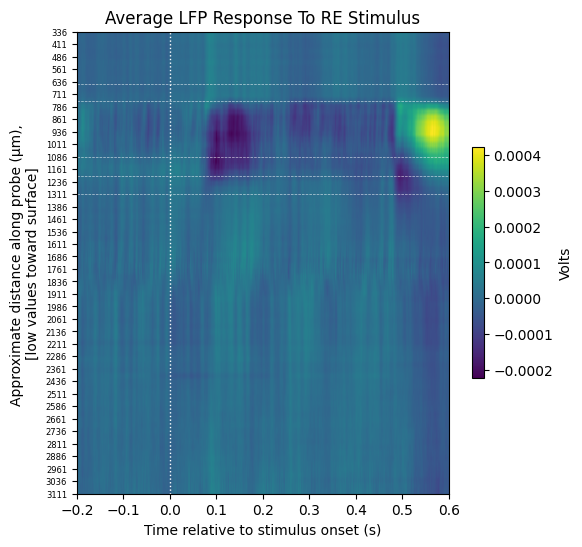

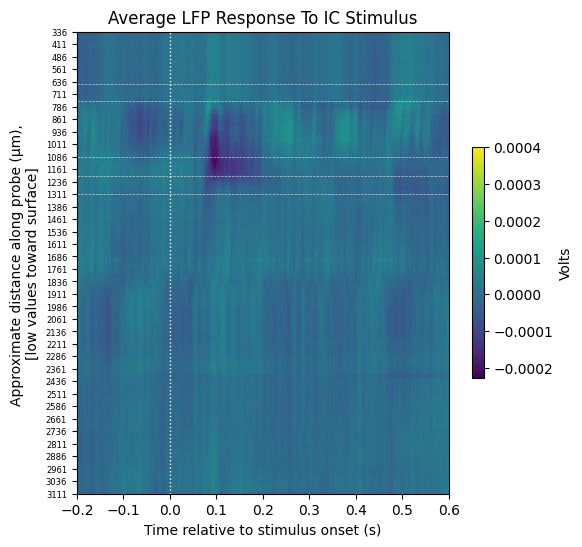

In [17]:
window_csd_IC = np.transpose(windows_IC, axes = (0, 2, 1))
avg_IC = np.mean(window_csd_IC, axis=0)

window_csd_RE = np.transpose(windows_RE, axes = (0, 2, 1))
avg_RE = np.mean(window_csd_RE, axis=0)

display_response_window(avg_RE[::-1],
                        window_start_time,
                        window_end_time,
                        title="Average LFP Response To RE Stimulus",
                        xlabel="Time relative to stimulus onset (s)",
                        ylabel="Approximate distance along probe (μm), \n[low values toward surface]",
                        cbar_label="Volts")
display_response_window(avg_IC[::-1],
                        window_start_time,
                        window_end_time,
                        title="Average LFP Response To IC Stimulus",
                        xlabel="Time relative to stimulus onset (s)",
                        ylabel="Approximate distance along probe (μm), \n[low values toward surface]",
                        cbar_label="Volts", vmax= 0.0004)

In [18]:
csd_RE = do_csd(avg_RE)
csd_IC = do_csd(avg_IC)

No lambda given, using defaults
Cross validating R (all lambda) : 0.23


KeyboardInterrupt: 

In [ ]:
csd_diff = csd_RE - csd_IC
display_response_window(csd_diff.transpose()[::-1],
                        window_start_time,
                        window_end_time,
                        title="Current Source Density Over Time - RE",
                        xlabel="Time relative to stimulus onset (s)",
                        ylabel="Approximate distance along probe (μm), \n[low values toward surface]",
                        cbar_label="V / mm²",
                        )


In [ ]:
v = np.percentile(np.abs(csd_RE), 99.5)   # or 99.5
vmi, vma = -v, v

display_response_window(csd_RE.transpose()[::-1],
                        window_start_time,
                        window_end_time,
                        title="Current Source Density Over Time - RE",
                        xlabel="Time relative to stimulus onset (s)",
                        ylabel="Approximate distance along probe (μm), \n[low values toward surface]",
                        cbar_label="V / mm²",
                        vmin=vmi,
                        vmax=vma)
vv = np.percentile(np.abs(csd_IC), 99.7)   # or 99.5
vvmi, vvma = -vv, vv

display_response_window(csd_IC.transpose()[::-1],
                        window_start_time,
                        window_end_time,
                        title="Current Source Density Over Time - IC",
                        xlabel="Time relative to stimulus onset (s)",
                        ylabel="Approximate distance along probe (μm), \n[low values toward surface]",
                        cbar_label="V / mm²",
                        vmin=vmi,
                        vmax=vma)

# CSD analysis across orientation, sessions

In [19]:
stim_key = "ICkcfg1"
id = 8      #8, 9 : real edge 3, 4 : IC
window_start_time = -0.2
window_end_time = 1.0
sampling_fq = 1000

In [24]:
ext_times, ext_lfp = extract_lfp(stim_key, id)
lfp_obj, lfp_tp, times = sampling_lfp(ext_lfp, ext_times, sampling_fq)
prep_lfp, prep_lfp_tp = preparation(lfp_obj)
twins = np.array([window_start_time, window_end_time])
windows = get_windows(prep_lfp, times, stim_key, sampling_fq, id)
window_csd = np.transpose(windows, axes = (0, 2, 1))
avg_window = np.mean(window_csd, axis=0)
csd = do_csd(avg_window)

LFP succesfully extracted. Shape : (electrodes, times) : (1000005, 84)
illusion trials : 30
LFP sampling succefully done. Sampling frequency : 1000Hz, shape : (800000, 84)
1200
Window succefully processed. Shape : (trial, times, electrodes) : (30, 1200, 84)
No lambda given, using defaults
Cross validating R (all lambda) : 0.23


KeyboardInterrupt: 